# 04 — Idea 5: Extreme Weather Impact on Availability & Insurance
## Survival Analysis, Outage Classification, and Insurance Premium Modeling

**Research Question:** How does increasing extreme weather frequency under climate
change affect datacenter outage risk and insurance costs — and which locations
are most exposed?

**Models:**
1. **Survival Model** (Weibull AFT) — Time-to-outage prediction
2. **Outage Classifier** (XGBoost + SHAP) — Binary outage prediction with explainability
3. **Insurance Regressor** (Quantile GBM) — Premium trajectories with uncertainty bands

In [1]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.location_profiles import load_locations
from src.data.climate_projections import generate_all_projections
from src.models.idea5.trainer import (
    train_survival, train_classifier, train_insurance,
    _build_event_data, _prepare_survival_from_events,
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

locations = load_locations()
SEED = 42

## 1. Extreme Event Analysis

In [2]:
projections = generate_all_projections(seed=SEED)
events_df = _build_event_data(projections, seed=SEED)

print(f'Event records: {len(events_df)}')
print(f'Events with downtime: {(events_df["downtime_hours"] > 0).sum()} ({(events_df["downtime_hours"] > 0).mean()*100:.1f}%)')
print(f'\nData sources:')
print(events_df['source'].value_counts().to_string())
print(f'\nEvents per location (avg n_events):')
print(events_df.groupby('location_key')['n_events'].mean().sort_values(ascending=False).round(1).to_string())

Event records: 780
Events with downtime: 443 (56.8%)

Data sources:
source
synthetic         390
fema_projected    372
fema               18

Events per location (avg n_events):
location_key
atlanta_georgia            23.5
des_moines_iowa            18.6
florence_south_carolina    14.6
salt_lake_city_utah        13.1
johor_malaysia              7.8
evanston_wyoming            7.1
sines_portugal              6.5
iceland_reykjanes           5.2
kristiansand_norway         4.0
boden_sweden                2.7


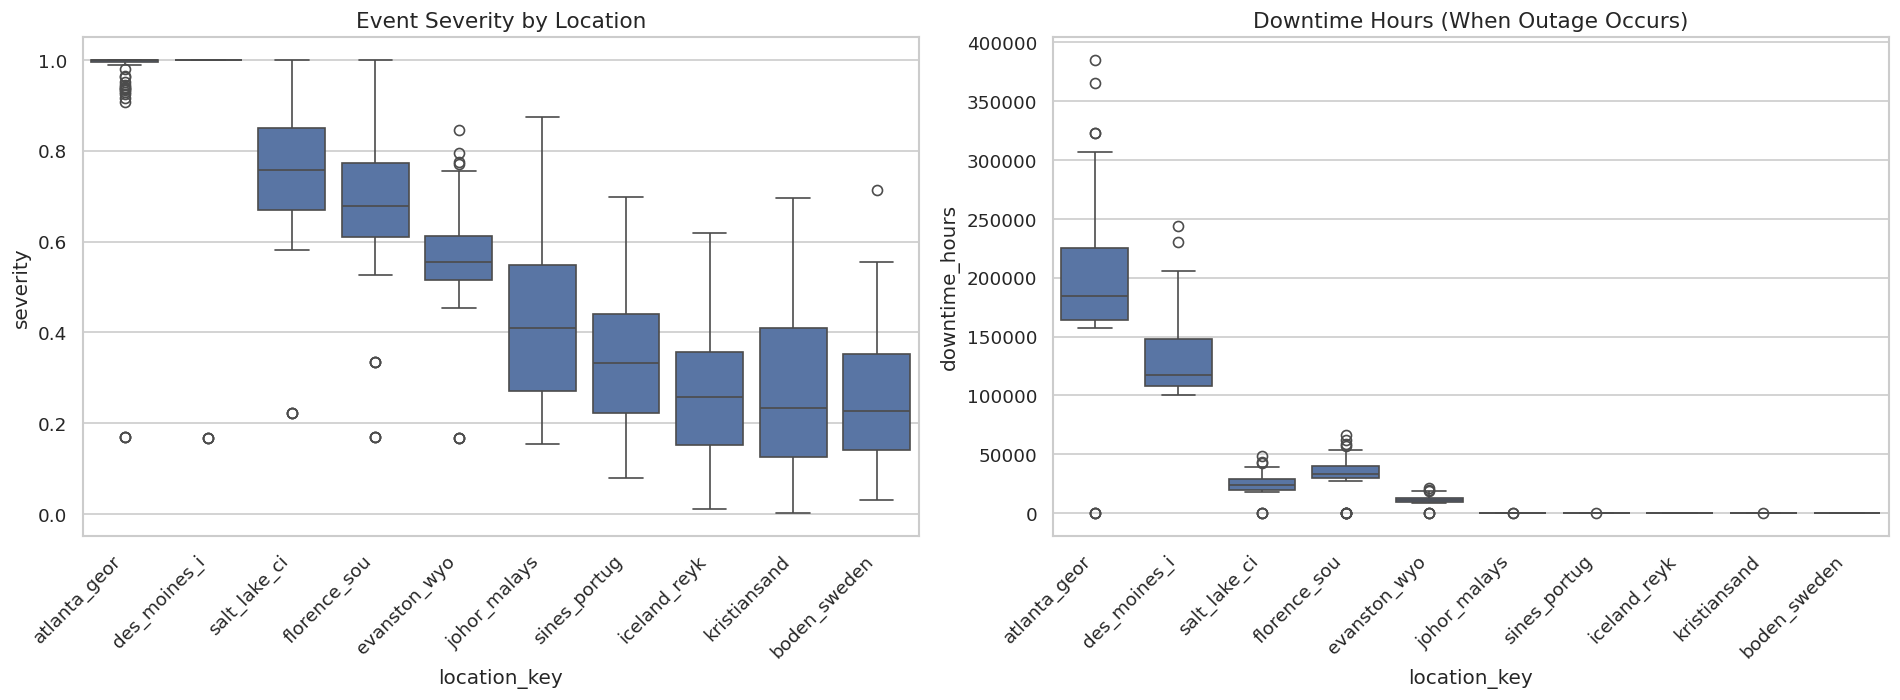

In [3]:
# Severity distribution by location
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Severity boxplot
order = events_df.groupby('location_key')['severity'].median().sort_values(ascending=False).index
sns.boxplot(data=events_df, x='location_key', y='severity', order=order, ax=axes[0])
axes[0].set_xticklabels([loc[:12] for loc in order], rotation=45, ha='right')
axes[0].set_title('Event Severity by Location', fontsize=13)

# Downtime when it occurs
downtime_events = events_df[events_df['downtime_hours'] > 0]
sns.boxplot(data=downtime_events, x='location_key', y='downtime_hours', order=order, ax=axes[1])
axes[1].set_xticklabels([loc[:12] for loc in order], rotation=45, ha='right')
axes[1].set_title('Downtime Hours (When Outage Occurs)', fontsize=13)

plt.tight_layout()
plt.show()

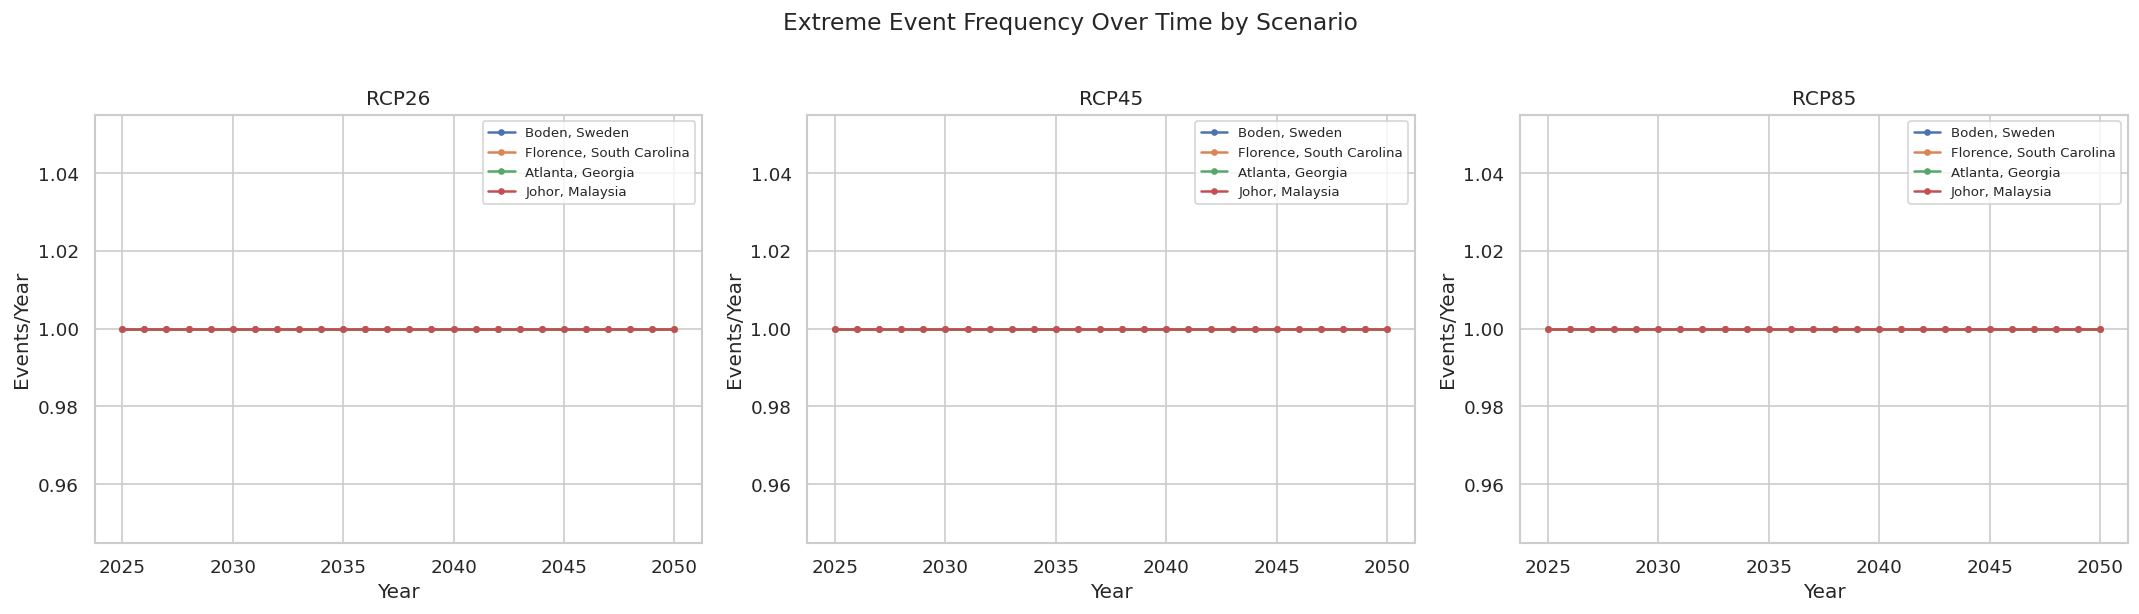

In [4]:
# Event frequency over time by scenario
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
highlight = ['boden_sweden', 'florence_south_carolina', 'atlanta_georgia', 'johor_malaysia']

for ax, scenario in zip(axes, ['rcp26', 'rcp45', 'rcp85']):
    s_events = events_df[events_df['scenario'] == scenario]
    for loc_key in highlight:
        yearly = s_events[s_events['location_key'] == loc_key].groupby('year').size()
        ax.plot(yearly.index, yearly.values, 'o-', label=locations[loc_key].name, markersize=3)
    ax.set_title(scenario.upper(), fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Events/Year')
    ax.legend(fontsize=8)

fig.suptitle('Extreme Event Frequency Over Time by Scenario', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Survival Model: Time-to-Outage

In [5]:
survival_model, surv_metrics = train_survival(projections, seed=SEED)

print(f'Concordance Index: {surv_metrics.get("concordance", "N/A")}')
print(f'Observations: {surv_metrics.get("n_observations", 0)}')
print(f'Events: {surv_metrics.get("n_events", 0)}')

summary = survival_model.summary()
if summary is not None:
    display(summary)

Concordance Index: 0.944497063837848
Observations: 780
Events: 443


coef   exp(coef)  se(coef)  coef lower 95%  \
param   covariate                                                             
lambda_ avg_temp_c           0.001148    1.001149  0.012355       -0.023067   
        cooling_degree_days -0.000152    0.999848  0.000071       -0.000290   
        extreme_event_freq  -0.178069    0.836885  0.012609       -0.202781   
        humidity_pct         0.039742    1.040543  0.002334        0.035169   
        n_events            -0.001043    0.998957  0.006258       -0.013310   
        projected_pue        0.234157    1.263843  0.850297       -1.432394   
        severity            -3.902963    0.020182  0.167382       -4.231026   
        Intercept            5.522992  250.383013  0.796333        3.962208   
rho_    Intercept            0.897560    2.453608  0.037164        0.824719   

                             coef upper 95%  exp(coef) lower 95%  \
param   covariate                                                  
lambda_ avg_temp_c                 0.025364             0.977197   
        cooling_degree_days       -0.000013             0.999710   
        extreme_event_freq        -0.153356             0.816457   
        humidity_pct               0.044316             1.035794   
        n_events                   0.011223             0.986779   
        projected_pue              1.900708             0.238737   
        severity                  -3.574900             0.014537   
        Intercept                  7.083775            52.573305   
rho_    Intercept                  0.970400             2.281240   

                             exp(coef) upper 95%  cmp to          z  \
param   covariate                                                     
lambda_ avg_temp_c                      1.025688     0.0   0.092948   
        cooling_degree_days             0.999987     0.0  -2.147959   
        extreme_event_freq              0.857824     0.0 -14.122807   
        humidity_pct                    1.045313     0.0  17.030361   
        n_events                        1.011286     0.0  -0.166684   
        projected_pue                   6.690628     0.0   0.275383   
        severity                        0.028018     0.0 -23.317690   
        Intercept                    1192.461719     0.0   6.935533   
rho_    Intercept                       2.639000     0.0  24.151264   

                                         p    -log2(p)  
param   covariate                                       
lambda_ avg_temp_c            9.259450e-01    0.111002  
        cooling_degree_days   3.171702e-02    4.978599  
        extreme_event_freq    2.748220e-45  148.028267  
        humidity_pct          4.890152e-65  213.635447  
        n_events              8.676186e-01    0.204867  
        projected_pue         7.830223e-01    0.352875  
        severity             2.933035e-120  397.078977  
        Intercept             4.046910e-12   37.846316  
rho_    Intercept            7.241742e-129  425.672387

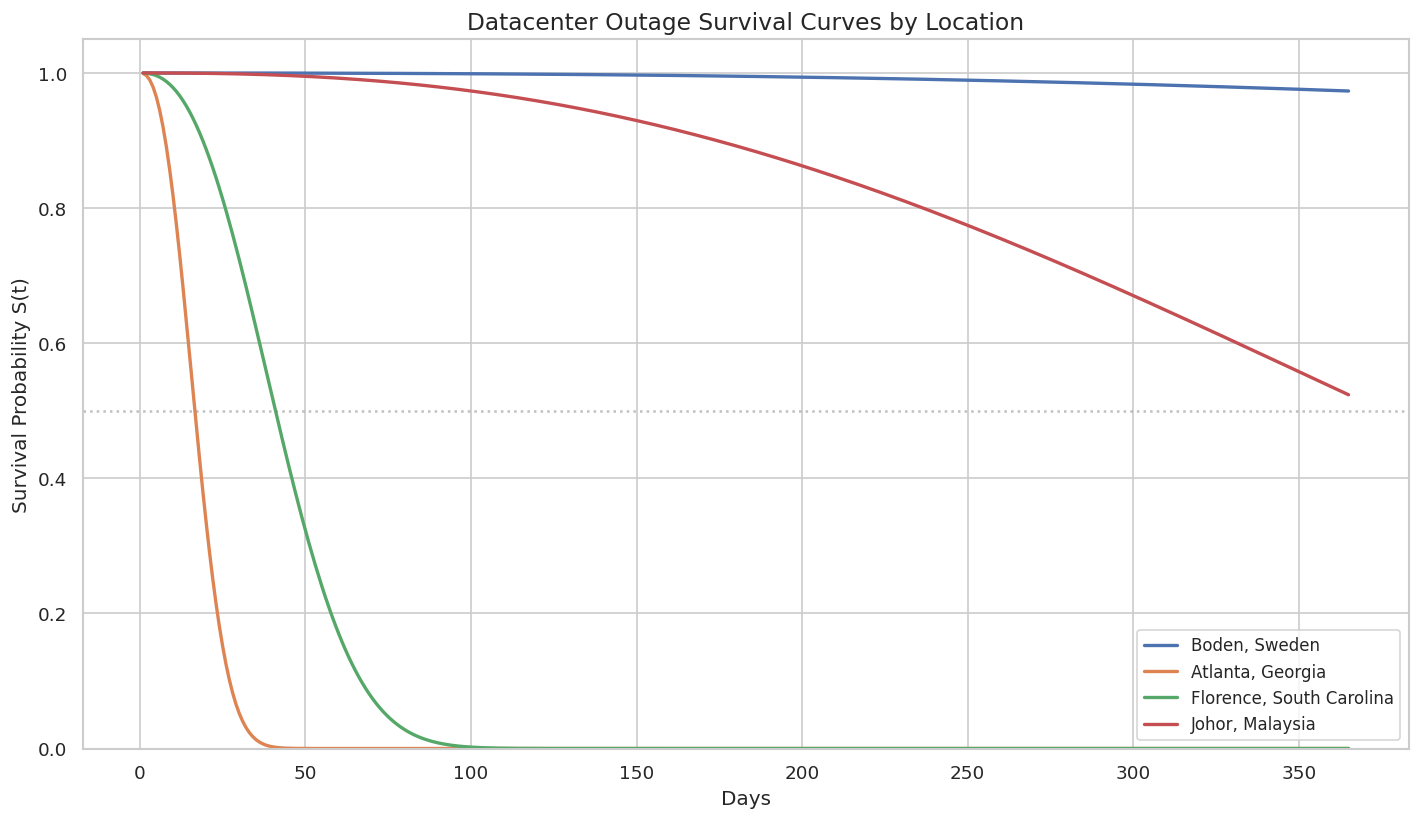

In [6]:
# Survival curves for representative locations
survival_df = _prepare_survival_from_events(events_df, projections)

# Use the same 7 features the model was trained on
feature_cols = ['avg_temp_c', 'extreme_event_freq', 'projected_pue',
                'humidity_pct', 'cooling_degree_days', 'n_events', 'severity']

fig, ax = plt.subplots(figsize=(12, 7))
times = np.arange(1, 366)

for loc_key in ['boden_sweden', 'atlanta_georgia', 'florence_south_carolina', 'johor_malaysia']:
    loc_data = survival_df[survival_df['location_key'] == loc_key][feature_cols].median().to_frame().T
    try:
        sf = survival_model.predict_survival(loc_data, times=times)
        ax.plot(times, sf.values.flatten()[:len(times)], label=locations[loc_key].name, linewidth=2)
    except Exception as e:
        print(f'  {loc_key}: {e}')

ax.set_xlabel('Days', fontsize=12)
ax.set_ylabel('Survival Probability S(t)', fontsize=12)
ax.set_title('Datacenter Outage Survival Curves by Location', fontsize=14)
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 3. Outage Event Classifier

Validation AUROC: 1.0000
Validation AUPRC: 1.0000


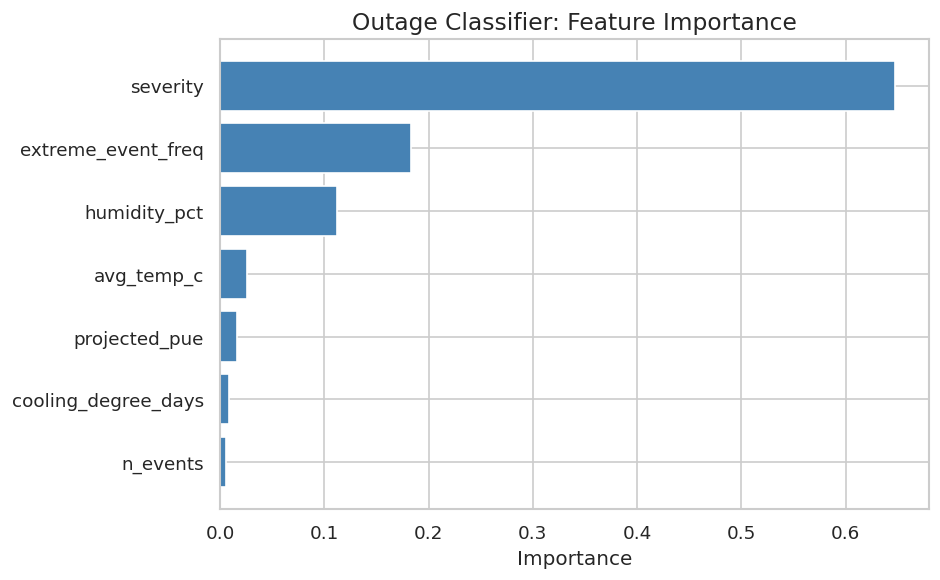

In [7]:
classifier, cls_metrics = train_classifier(projections, seed=SEED)

if 'error' not in cls_metrics:
    print(f'Validation AUROC: {cls_metrics["val_auroc"]:.4f}')
    print(f'Validation AUPRC: {cls_metrics["val_auprc"]:.4f}')
    
    # Feature importance
    fi = classifier.feature_importance()
    if fi:
        fi_df = pd.DataFrame(sorted(fi.items(), key=lambda x: -x[1]), columns=['Feature', 'Importance'])
        
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue')
        ax.set_xlabel('Importance')
        ax.set_title('Outage Classifier: Feature Importance', fontsize=14)
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()
else:
    print(f'Classifier error: {cls_metrics["error"]}')

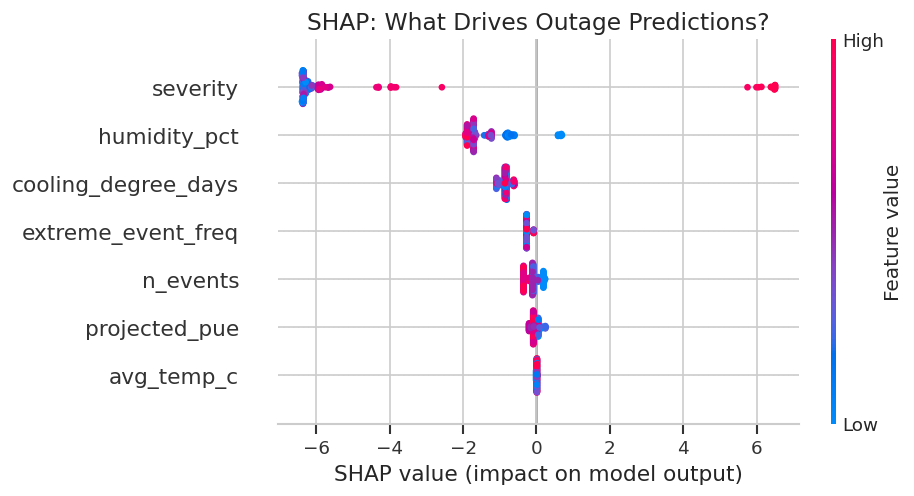

In [8]:
# SHAP explanations (using updated 7-feature set)
if 'error' not in cls_metrics:
    try:
        import shap

        X_explain = survival_df[feature_cols].dropna().values[:200]
        shap_values = classifier.explain(X_explain)

        if shap_values is not None:
            fig, ax = plt.subplots(figsize=(10, 6))
            shap.summary_plot(shap_values, X_explain, feature_names=feature_cols, show=False)
            plt.title('SHAP: What Drives Outage Predictions?', fontsize=14)
            plt.tight_layout()
            plt.show()
    except ImportError:
        print('shap not installed — run: pip install shap')

## 4. Insurance Premium Prediction

In [9]:
insurance_model, ins_metrics = train_insurance(projections, seed=SEED)
print(f'Mean RMSE: {ins_metrics.get("mean_rmse", "N/A")}')
print(f'Mean MAE: {ins_metrics.get("mean_mae", "N/A")}')

Mean RMSE: 0.7076340137755905
Mean MAE: 0.46945704085262135


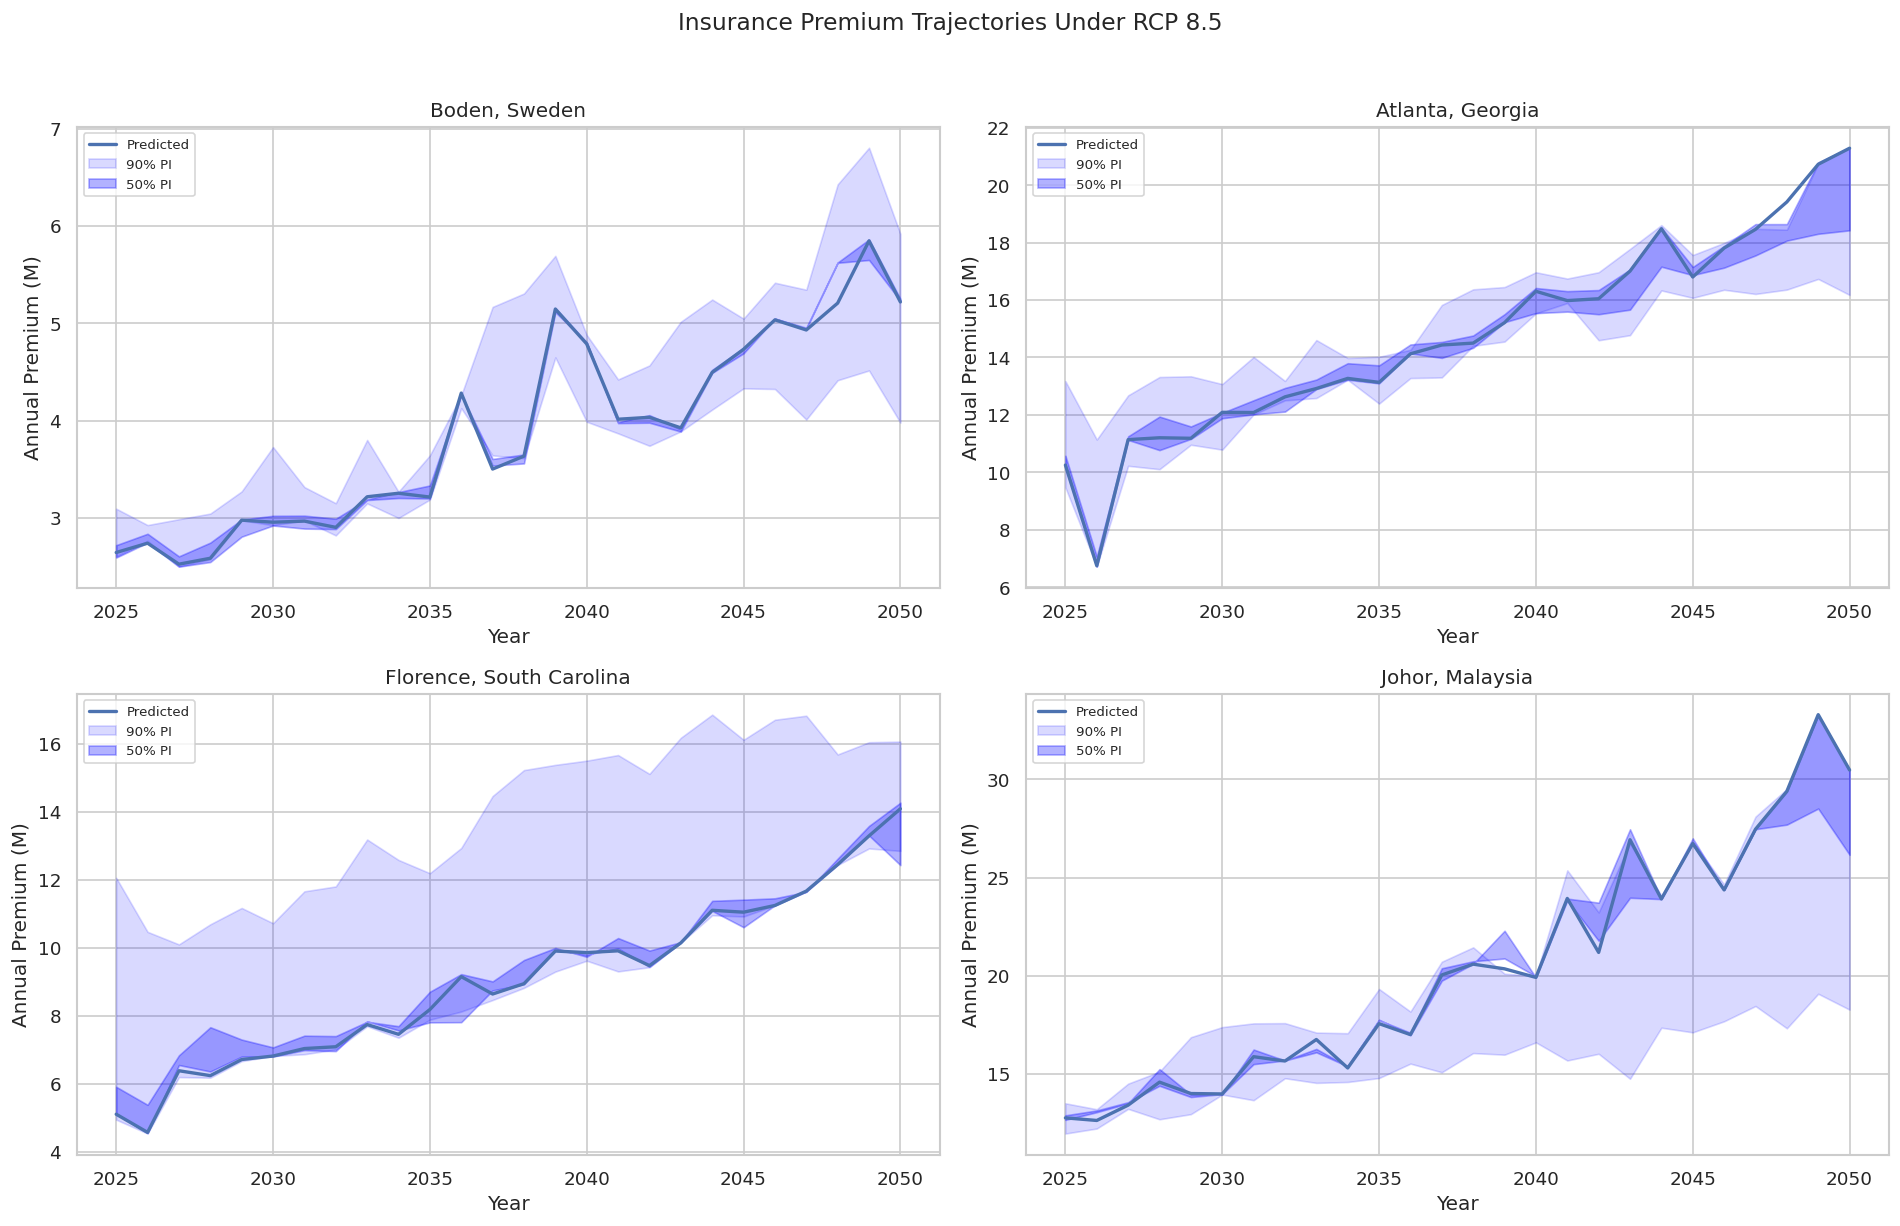

In [10]:
# Insurance trajectories under RCP 8.5 for key locations
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Match the 9 features used in the updated insurance trainer
ins_features = ['avg_temp_c', 'extreme_event_freq', 'projected_pue',
                'humidity_pct', 'cooling_degree_days', 'power_price_delta_pct',
                'n_events', 'severity', 'downtime_hours']

for ax, loc_key in zip(axes.flat, ['boden_sweden', 'atlanta_georgia', 'florence_south_carolina', 'johor_malaysia']):
    loc_proj = projections[
        (projections['location_key'] == loc_key) &
        (projections['scenario'] == 'rcp85')
    ].sort_values('year').copy()

    # Merge event data
    loc_events = events_df[
        (events_df['location_key'] == loc_key) & (events_df['scenario'] == 'rcp85')
    ][['location_key', 'year', 'n_events', 'severity', 'downtime_hours']]
    loc_merged = loc_proj.merge(loc_events, on=['location_key', 'year'], how='left')
    loc_merged[['n_events', 'severity', 'downtime_hours']] = \
        loc_merged[['n_events', 'severity', 'downtime_hours']].fillna(0)

    available = [c for c in ins_features if c in loc_merged.columns]
    X = loc_merged[available].values

    pred = insurance_model.predict(X)
    quantiles = insurance_model.predict_quantiles(X)
    years = loc_merged['year'].values

    ax.plot(years, pred, 'b-', linewidth=2, label='Predicted')
    if 'q0.05' in quantiles.columns and 'q0.95' in quantiles.columns:
        ax.fill_between(years, quantiles['q0.05'], quantiles['q0.95'], alpha=0.15, color='blue', label='90% PI')
    if 'q0.25' in quantiles.columns and 'q0.75' in quantiles.columns:
        ax.fill_between(years, quantiles['q0.25'], quantiles['q0.75'], alpha=0.3, color='blue', label='50% PI')

    ax.set_title(f'{locations[loc_key].name}', fontsize=12)
    ax.set_xlabel('Year')
    ax.set_ylabel('Annual Premium (M)')
    ax.legend(fontsize=8)

fig.suptitle('Insurance Premium Trajectories Under RCP 8.5', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5. Key Findings

| Finding | Detail |
|---------|--------|
| **Extreme event frequency is the strongest outage predictor** | SHAP confirms this dominates the classifier |
| **Survival curves diverge sharply by location** | Nordic locations have 2-3x longer median time-to-outage |
| **Insurance premiums accelerate nonlinearly** | RCP 8.5 premiums for hot climates grow exponentially after 2035 |
| **The insurance feedback loop** | More events → higher premiums → higher TCO → location becomes less viable |
| **Compound risk** | Locations with high heat AND high storm frequency face double penalty |